In [1]:
# Define the verbose variable
verbose = False

# Check if we're running in a Jupyter Notebook (not compiled script)
try:
    __IPYTHON__
    verbose = True  # Set verbose to True if running in a Jupyter Notebook
except NameError:
    pass  # Do nothing if we're not in a notebook

In [2]:
# All the imports

import torch
from torch.utils.data import TensorDataset
from torch import nn
import matplotlib.pyplot as plt

from the_ml.load_dataset import labelList, get_data
from the_ml.preprocess import preprocess_dataset
from the_ml import bigmodel

from ml_util.eeg_util import plotEEG, plotTimeFreqEEG
from ml_util.checkpoint import checkpoint
from ml_util.data_module import DataModule
from ml_util.trainer import GoodClassificationModel, GoodTrainer
from ml_util.logger import WandBLogger, print_stats
from ml_util.reporter import getTestResults
from ml_util.plot import plot_confusion_matrix

# To make it reproducible
torch.manual_seed(42)

/dgxb_home/ext03/eeg-ml/EEG-classification/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print("Loading raw dataset")
X_raw, y = checkpoint(lambda: get_data(verbose=True), "raw_input")
print(f"Raw input dataset size: {X_raw.shape}")

Loading raw dataset
Raw input dataset size: torch.Size([480, 32, 3200])


# The SAM40 Dataset

It consists of electroencephalograms (EEG) of people while they perform tasks.

You can find the dataset [here](https://figshare.com/articles/dataset/SAM_40_Dataset_of_40_Subject_EEG_Recordings_to_Monitor_the_Induced-Stress_while_performing_Stroop_Color-Word_Test_Arithmetic_Task_and_Mirror_Image_Recognition_Task/14562090)

We extract the dataset to obtain 480 samples (120 for each task among Stroop, Relax, Mirror_Image, and Arithmetic).
Each sample has the record of the 32 electrods of the EEG over 25 seconds at 128Hz (3200 points)

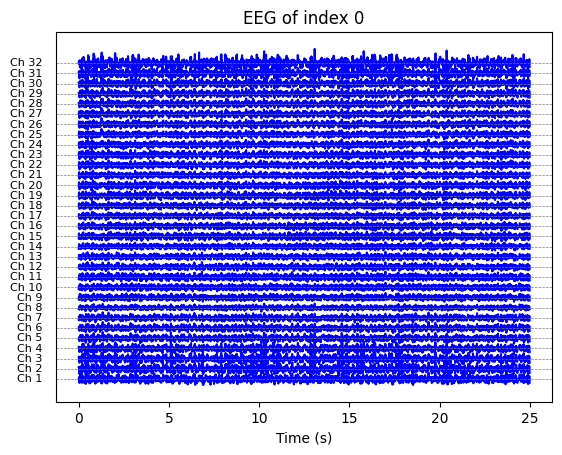

Arithmetic


In [4]:
if verbose:
    plotEEG(X_raw[0], title="index 0")
    print(labelList[y[0]])

## Preprocessing

We don't want to feed the raw inputs to our model, we will extract features from it.

The approach used was to use a time-frequency spectrogram with the alpha, beta, gamma, delta and theta bands (those are intervals in the frequency domain).

After the preprocessing step we have a 32 channels 5x101 image for each sample. 5 corresponds to the 5 frequency intervals and 101 are the time intervals.

In [5]:
hyperparams ={"bands_param": "five"} # hop time in seconds

# Applies preprocessing
print("Preprocessing input data")
X = checkpoint(lambda : preprocess_dataset(X_raw, hyperparams["bands_param"], verbose=True), "preprocessed")
print(f"Preprocessed inpu dataset shape: {X.shape}")

# Stores in a TensorDataset
dataset = DataModule(X, y, val_part=0.15, test_part=0.15)

# Uncomment to reduce the size of the dataset
# dataset = dataset.get_part(0.1)

Preprocessing input data


Batch function apply:   0%|                                                                          | 0/15 [00:00<?, ?it/s]

Batch function apply:   7%|████▍                                                             | 1/15 [00:01<00:15,  1.08s/it]

Batch function apply:  13%|████████▊                                                         | 2/15 [00:02<00:13,  1.07s/it]

Batch function apply:  20%|█████████████▏                                                    | 3/15 [00:03<00:12,  1.07s/it]

...

Batch function apply:  87%|████████████████████████████████████████████████████████▎        | 13/15 [00:13<00:02,  1.07s/it]

Batch function apply:  93%|████████████████████████████████████████████████████████████▋    | 14/15 [00:14<00:01,  1.07s/it]

Batch function apply: 100%|█████████████████████████████████████████████████████████████████| 15/15 [00:16<00:00,  1.07s/it]

Batch function apply: 100%|█████████████████████████████████████████████████████████████████| 15/15 [00:16<00:00,  1.07s/it]

Preprocessed inpu dataset shape: torch.Size([480, 32, 5, 101])


<Figure size 640x480 with 0 Axes>

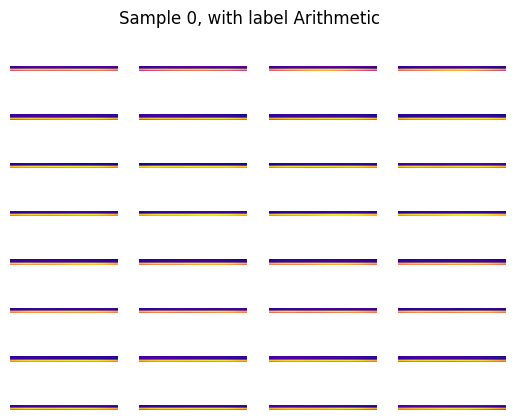

<Figure size 640x480 with 0 Axes>

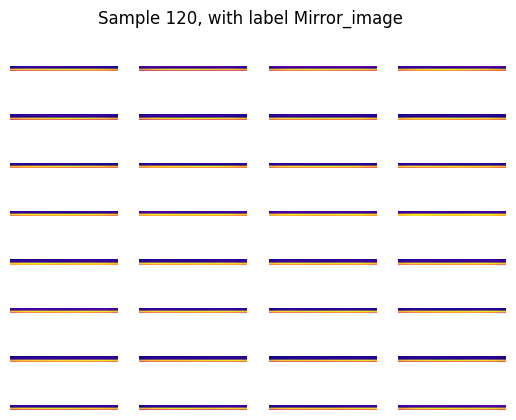

<Figure size 640x480 with 0 Axes>

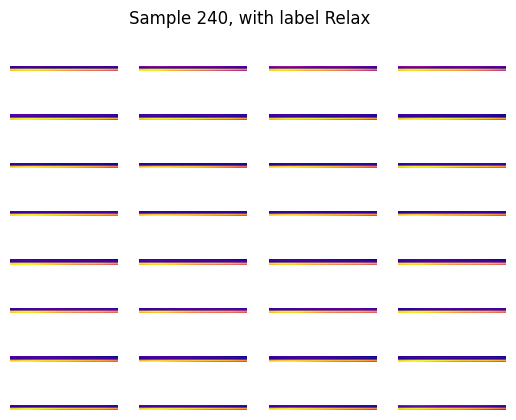

<Figure size 640x480 with 0 Axes>

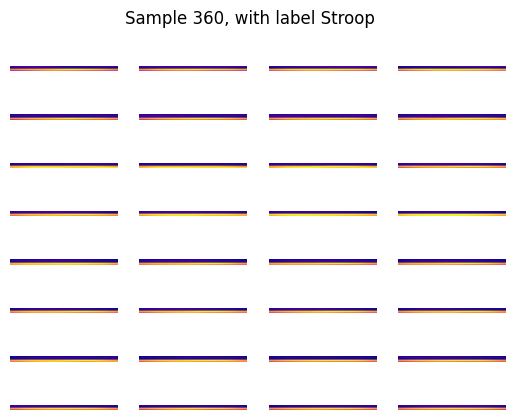

In [6]:
if verbose:
    for label in range(4):
        sampleId = torch.where(y==label)[0][0]
        plt.figure()
        fig, axes = plotTimeFreqEEG(X[sampleId])
        #plt.imshow(X[sampleId][0])
        fig.suptitle(f"Sample {sampleId}, with label {labelList[y[sampleId]]}")
    plt.show()

## The model

Here are the layers of the model: 
- BatchNorm2d

- Conv2d          
32 to 128 channels, kernel_size of 5, stride 1, padding 2

- Dropout2d       
0.3 probability of channel dropout

- BatchNorm2d

- ReLU

- Conv2d          
128 to 64 channels, kernel_size of 5, stride 1, padding 2

- Dropout2d       
0.2 probability of channel dropout

- BatchNorm2d

- ReLU

- Conv2d          
64 to 32 channels, kernel_size of 5, stride 1, padding 2

- Dropout2d       
0.2 probability of channel dropout

- BatchNorm2d

- ReLU

- Flatten

- Fully-Connected 
32*101*5 to 128 layers

- Dropout         
0.5 probability of neuron dropout

- BatchNorm

- ReLU

- Fully-Connected 
128 to 4 layers

- SoftMax loss


## The training

- Adam optimizer was used
- L2 regularization added to the loss
- Every epoch, the learning rate is reduced by 1%

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU" if torch.cuda.is_available() else "CPU")

hyperparams |= {
    'lr': 1e-4,
    'weight_decay': 2e-2,
    'batch_size': 512
}
model = bigmodel.model(X[0], hyperparams)
loss_fn = nn.CrossEntropyLoss()

classification_model = GoodClassificationModel(model, loss_fn, hyperparams, device, 4)
trainer = GoodTrainer()

def babysitter(goodModel):
    goodModel.hyperparameters['lr'] = 0.99 * goodModel.hyperparameters['lr']

trainer.add_babysitter(babysitter)
trainer.add_logger(lambda res: print_stats(res, print_every=100))
trainer.add_logger(WandBLogger(hyperparams, labelList, model))

GPU


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


wandb: Appending key for api.wandb.ai to your netrc file: /dgxb_home/ext03/.netrc


wandb: Currently logged in as: ulyssedurand (ulyssedurand-ens-de-lyon) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Tracking run with wandb version 0.19.10


wandb: Run data is saved locally in /dgxb_home/ext03/eeg-ml/EEG-classification/wandb/run-20250502_183346-he3fxq5w
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run usual-snowflake-216


wandb: ⭐️ View project at https://wandb.ai/ulyssedurand-ens-de-lyon/EEG%20Classification


wandb: 🚀 View run at https://wandb.ai/ulyssedurand-ens-de-lyon/EEG%20Classification/runs/he3fxq5w


In [8]:
trainer.train(classification_model, dataset, 1500)

Epoch:  100    | tl: 1.064623, ta: 0.550595    |    vl: 1.350533, va: 0.333333


Epoch:  200    | tl: 0.764489, ta: 0.723214    |    vl: 1.283745, va: 0.402778


Epoch:  300    | tl: 0.700200, ta: 0.750000    |    vl: 1.237283, va: 0.416667


Epoch:  400    | tl: 0.638300, ta: 0.776786    |    vl: 1.235933, va: 0.430556


Epoch:  500    | tl: 0.654449, ta: 0.794643    |    vl: 1.233745, va: 0.430556


...

Epoch: 1100    | tl: 0.614900, ta: 0.800595    |    vl: 1.230605, va: 0.430556


Epoch: 1200    | tl: 0.666809, ta: 0.770833    |    vl: 1.230071, va: 0.430556


Epoch: 1300    | tl: 0.636793, ta: 0.782738    |    vl: 1.230234, va: 0.430556


Epoch: 1400    | tl: 0.618528, ta: 0.782738    |    vl: 1.231158, va: 0.430556


Epoch: 1500    | tl: 0.676743, ta: 0.764881    |    vl: 1.231470, va: 0.430556


# Results

 Test accuracy: 0.5138888888888888


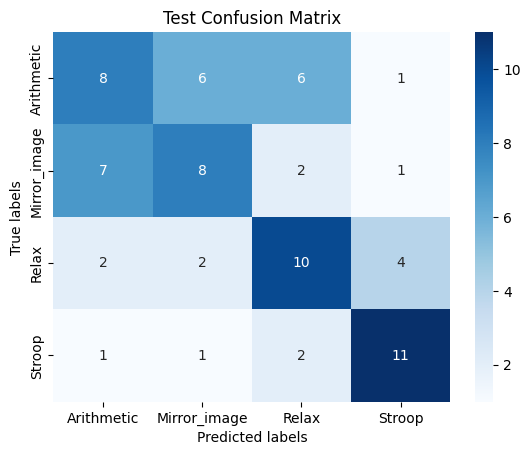

In [9]:
res = (getTestResults(dataset, classification_model))
print(f" Test accuracy: {res['test_acc']}")
test_preds, test_labels = res["test_confusion"]
plot_confusion_matrix(test_preds, test_labels, labelList)
